In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD
from sklearn.metrics import classification_report, confusion_matrix

I0000 00:00:1790670546.849834    6251 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790670546.852721    6251 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790670547.273319    6251 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790670548.617067    6251 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape :", x_test.shape)
print("Testing labels shape:", y_test.shape)

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing data shape : (10000, 28, 28)
Testing labels shape: (10000,)


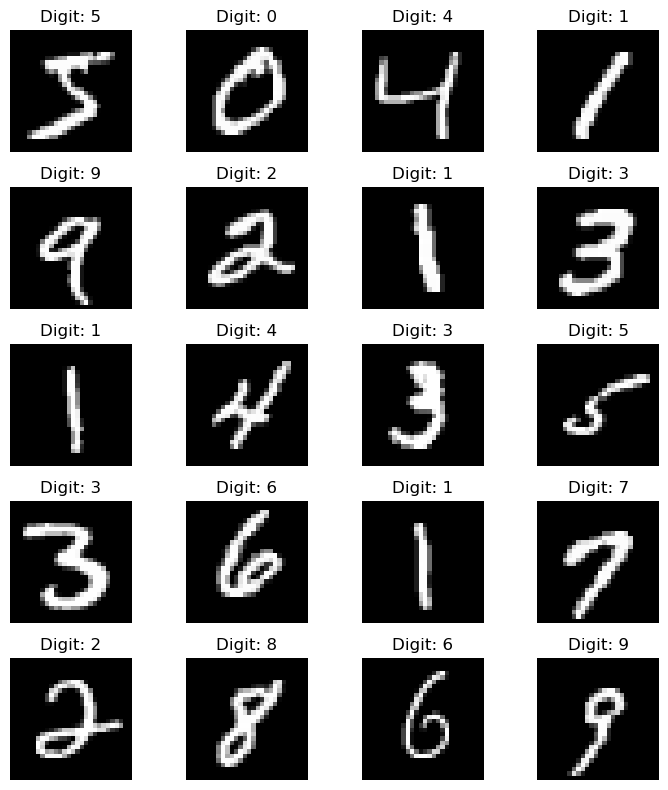

In [5]:
plt.figure(figsize=(8, 8))
for i in range(20):
 plt.subplot(5, 4, i + 1)
 plt.imshow(x_train[i], cmap="gray")
 plt.title("Digit: " + str(y_train[i]))
 plt.axis("off")
 plt.tight_layout()
plt.show()

In [6]:
x_train = x_train.reshape(x_train.shape[0], 784).astype("float32")
x_test = x_test.reshape(x_test.shape[0], 784).astype("float32")

In [7]:
x_train = x_train / 255.0
x_test = x_test / 255.0
print("After preprocessing:")
print("Training data shape:", x_train.shape)
print("Testing data shape :", x_test.shape)

After preprocessing:
Training data shape: (60000, 784)
Testing data shape : (10000, 784)


In [20]:
model = Sequential([Input(shape=(784,)),Dense(64, activation="sigmoid"),Dense(10, activation="softmax")
])

In [21]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(
optimizer=SGD(learning_rate=0.03),
loss="sparse_categorical_crossentropy",
metrics=["accuracy"])

In [23]:
history = model.fit(
x_train,

y_train,
batch_size=128,
epochs=20,
validation_split=0.1,
verbose=1
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6221 - loss: 1.7619 - val_accuracy: 0.7973 - val_loss: 1.2419
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7961 - loss: 1.0226 - val_accuracy: 0.8610 - val_loss: 0.7688
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8362 - loss: 0.7315 - val_accuracy: 0.8832 - val_loss: 0.5808
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8590 - loss: 0.5990 - val_accuracy: 0.8908 - val_loss: 0.4834
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8715 - loss: 0.5230 - val_accuracy: 0.9005 - val_loss: 0.4246
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8809 - loss: 0.4738 - val_accuracy: 0.9052 - val_loss: 0.3865
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8860 - loss: 0.4395 - val_accuracy: 0.9100 - val_loss: 0.3582
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 990us/step - accuracy: 0.8910 - loss: 0.4140 - val_accuracy: 

In [24]:
test_loss, test_accuracy = model.evaluate(
x_test,
y_test,
verbose=0
)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


Test Loss: 0.28371578454971313
Test Accuracy: 0.9200000166893005


In [25]:
y_probability = model.predict(x_test, verbose=0)


In [26]:
y_pred = np.argmax(y_probability, axis=1)

In [27]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[ 962    0    3    2    0    4    6    1    2    0]
 [   0 1110    2    2    0    1    4    2   14    0]
 [  10    7  920   14   15    2   12   12   35    5]
 [   3    0   21  925    0   24    2   13   16    6]
 [   1    3    5    0  921    1   11    2    6   32]
 [  10    3    4   49   10  764   16    6   24    6]
 [  15    3    4    1   13   14  904    1    3    0]
 [   3    9   23    8   10    0    0  944    3   28]
 [   8    7    8   25   10   22   12   12  858   12]
 [  13    7    3   12   46    9    0   21    6  892]]


In [28]:
print("\nClassification Report:")
print(
classification_report(
y_test,
y_pred,
zero_division=0
)
)


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       980
           1       0.97      0.98      0.97      1135
           2       0.93      0.89      0.91      1032
           3       0.89      0.92      0.90      1010
           4       0.90      0.94      0.92       982
           5       0.91      0.86      0.88       892
           6       0.93      0.94      0.94       958
           7       0.93      0.92      0.92      1028
           8       0.89      0.88      0.88       974
           9       0.91      0.88      0.90      1009

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



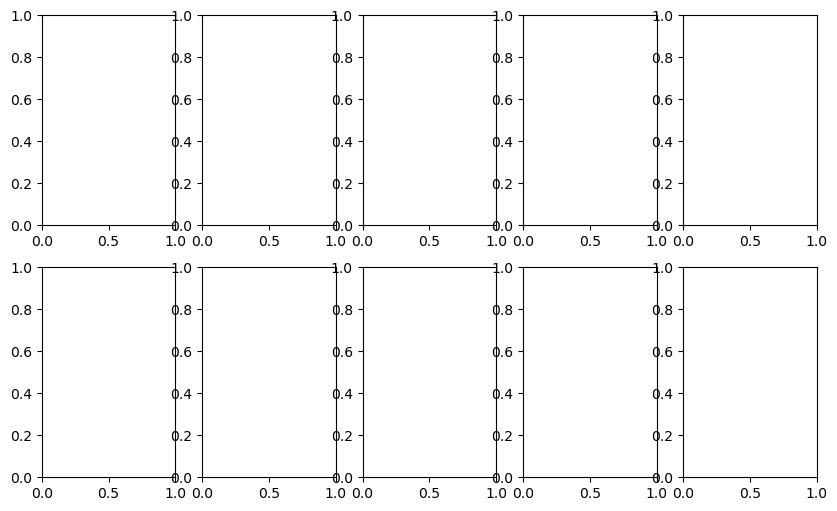

In [30]:
plt.figure(figsize=(10, 6))

for i in range(10):
 plt.subplot(2, 5, i + 1)

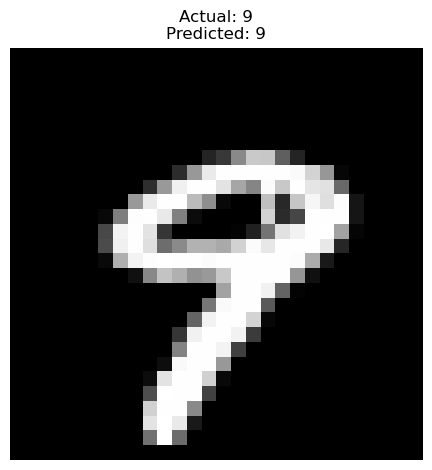

In [31]:
image = x_test[i].reshape(28, 28)

plt.imshow(image, cmap="gray")
plt.title(
"Actual: " + str(y_test[i]) +
"\nPredicted: " + str(y_pred[i])
)
plt.axis("off")

plt.tight_layout()
plt.show()

Text(0, 0.5, 'epoch')

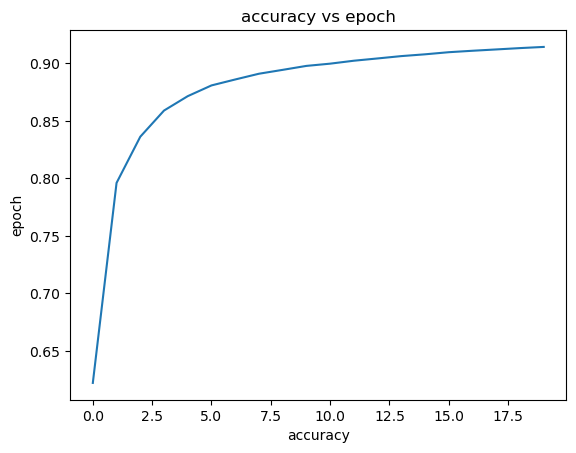

In [37]:
plt.plot(history.history['accuracy'])
plt.title('accuracy vs epoch')
plt.xlabel('accuracy')
plt.ylabel('epoch')



Text(0, 0.5, 'epoch')

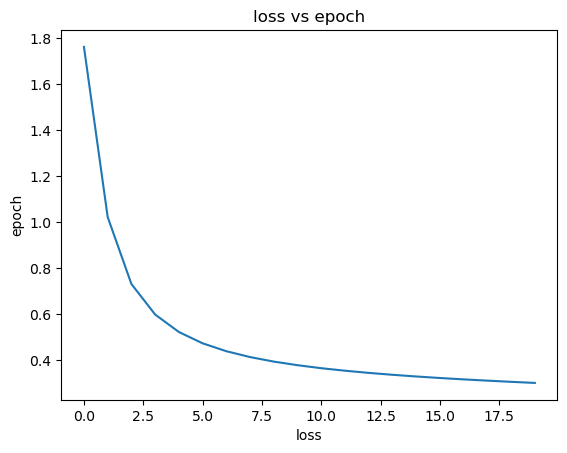

In [36]:
plt.plot(history.history['loss'])
plt.title('loss vs epoch')
plt.xlabel('loss')
plt.ylabel('epoch')
